# Notebook 04 — Evaluation & Analysis

## Objective
Evaluate the model trained in Notebook 03 on the test set, analyzing:
- Overall accuracy per task
- Confusion matrix per task
- Per-class metrics (precision, recall, F1)
- Examples of correct and incorrect predictions

## Inputs
- `best_model.pt` — best model checkpoint (Notebook 03)
- `test.csv` — test set with 6,223 examples (Notebook 02)
- DeepFashion-MultiModal images

## Tasks
| Task | Classes |
|---|---|
| sleeve_length | sleeveless, short, medium, long, not long-sleeve |
| upper_fabric | denim, cotton, leather, furry, knitted, chiffon, other |
| upper_color | floral, graphic, striped, pure color, lattice, other, color block |

# 1 — Imports & Environment Check

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image

from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"PyTorch version: {torch.__version__}")

Device: cuda
GPU: Tesla T4
PyTorch version: 2.10.0+cu128


# 2 — Paths & Configuration

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
NB02_DIR  = Path("/kaggle/input/notebooks/miguelmirandar/02-data-preparation")
NB03_DIR  = Path("/kaggle/input/notebooks/miguelmirandar/03-model-architecture-and-training")
IMAGE_DIR = Path("/kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/images/images")
CKPT_PATH = NB03_DIR / "checkpoints" / "best_model.pt"
OUT_DIR   = Path("/kaggle/working")

# ── Task definition ─────────────────────────────────────────────────────────
TASKS = {
    "sleeve_length": 5,
    "upper_fabric":  7,
    "upper_color":   7,
}

SLEEVE_MAP  = {0:"sleeveless", 1:"short", 2:"medium", 3:"long", 4:"not long-sleeve"}
FABRIC_MAP  = {0:"denim", 1:"cotton", 2:"leather", 3:"furry", 4:"knitted", 5:"chiffon", 6:"other"}
PATTERN_MAP = {0:"floral", 1:"graphic", 2:"striped", 3:"pure color", 4:"lattice", 5:"other", 6:"color block"}

LABEL_MAPS = {
    "sleeve_length": SLEEVE_MAP,
    "upper_fabric":  FABRIC_MAP,
    "upper_color":   PATTERN_MAP,
}

IMG_SIZE   = 224
BATCH_SIZE = 64

print(f"Checkpoint : {CKPT_PATH}")
print(f"Test CSV   : {NB02_DIR / 'test.csv'}")
print(f"Checkpoint exists: {CKPT_PATH.exists()}")

Checkpoint : /kaggle/input/notebooks/miguelmirandar/03-model-architecture-and-training/checkpoints/best_model.pt
Test CSV   : /kaggle/input/notebooks/miguelmirandar/02-data-preparation/test.csv
Checkpoint exists: True


# 3 — Dataset & DataLoader (test set only)

In [4]:
class GarmentDataset(Dataset):
    """Loads garment images and returns (image, labels_dict) pairs."""

    def __init__(self, csv_path, image_dir, transform=None):
        self.df        = pd.read_csv(csv_path)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = self.image_dir / row["image_name"]
        image    = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        labels = {
            "sleeve_length": torch.tensor(row["sleeve_length"], dtype=torch.long),
            "upper_fabric":  torch.tensor(row["upper_fabric"],  dtype=torch.long),
            "upper_color":   torch.tensor(row["upper_color"],   dtype=torch.long),
        }
        return image, labels


# ── Test transform (no augmentation) ─────────────────────────────────────────
test_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

test_ds = GarmentDataset(NB02_DIR / "test.csv", IMAGE_DIR, test_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Test samples : {len(test_ds):,}")
print(f"Test batches : {len(test_loader)}")

# Sanity check
imgs, labels = next(iter(test_loader))
print(f"Batch image shape : {imgs.shape}")
print(f"sleeve_length     : {labels['sleeve_length'][:8].tolist()}")

Test samples : 6,224
Test batches : 98
Batch image shape : torch.Size([64, 3, 224, 224])
sleeve_length     : [0, 0, 1, 3, 0, 0, 3, 0]


# 4 — Load Model

In [5]:
class GarmentClassifier(nn.Module):
    """
    EfficientNet-B0 backbone with 3 parallel classification heads:
      - sleeve_length (5 classes)
      - upper_fabric  (7 classes)
      - upper_color   (7 classes)
    """

    def __init__(self, tasks: dict):
        super().__init__()

        backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

        self.features = backbone.features
        self.avgpool  = backbone.avgpool

        in_features = backbone.classifier[1].in_features  # 1280

        self.heads = nn.ModuleDict({
            task: nn.Sequential(
                nn.Dropout(p=0.3),
                nn.Linear(in_features, num_classes),
            )
            for task, num_classes in tasks.items()
        })

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return {task: head(x) for task, head in self.heads.items()}


# ── Load checkpoint ───────────────────────────────────────────────────────────
checkpoint = torch.load(CKPT_PATH, map_location=device)

model = GarmentClassifier(TASKS).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(f"Model loaded from epoch : {checkpoint['epoch']}")
print(f"Val loss at checkpoint  : {checkpoint['val_loss']:.4f}")
print("Val acc at checkpoint:")
for task, acc in checkpoint["val_acc"].items():
    print(f"  {task}: {acc:.4f}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s] 


Model loaded from epoch : 15
Val loss at checkpoint  : 11.6618
Val acc at checkpoint:
  sleeve_length: 0.0175
  upper_fabric: 0.0877
  upper_color: 0.8514


# 5 — Run Inference on Test Set

In [6]:
all_preds  = {task: [] for task in TASKS}
all_labels = {task: [] for task in TASKS}

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs = imgs.to(device)

        outputs = model(imgs)

        for task in TASKS:
            preds = outputs[task].argmax(dim=1).cpu().numpy()
            gt    = labels[task].numpy()
            all_preds[task].extend(preds)
            all_labels[task].extend(gt)

# Convert to numpy arrays
all_preds  = {task: np.array(all_preds[task])  for task in TASKS}
all_labels = {task: np.array(all_labels[task]) for task in TASKS}

# Overall accuracy per task
print("Test Accuracy:")
for task in TASKS:
    acc = (all_preds[task] == all_labels[task]).mean()
    print(f"  {task}: {acc:.4f}")

Evaluating:   0%|          | 0/98 [00:00<?, ?it/s]

Test Accuracy:
  sleeve_length: 0.0169
  upper_fabric: 0.0844
  upper_color: 0.8438


# 6 — Classification Report per Task

In [7]:
for task in TASKS:
    label_names = [LABEL_MAPS[task][i] for i in range(TASKS[task])]

    print(f"\n{'='*60}")
    print(f" Task: {task}")
    print(f"{'='*60}")
    print(classification_report(
        all_labels[task],
        all_preds[task],
        target_names=label_names,
        zero_division=0
    ))


 Task: sleeve_length
                 precision    recall  f1-score   support

     sleeveless       0.00      0.00      0.00      2561
          short       0.00      0.00      0.00      1339
         medium       0.90      0.30      0.44       332
           long       0.00      0.00      0.00      1985
not long-sleeve       0.00      1.00      0.00         7

       accuracy                           0.02      6224
      macro avg       0.18      0.26      0.09      6224
   weighted avg       0.05      0.02      0.02      6224


 Task: upper_fabric
              precision    recall  f1-score   support

       denim       0.78      0.73      0.76        70
      cotton       0.00      0.00      0.00      5047
     leather       0.00      0.94      0.01        16
       furry       0.47      0.89      0.62        18
     knitted       0.83      0.75      0.79       330
     chiffon       0.85      0.26      0.39       732
       other       0.01      0.82      0.02        11

    acc

# 7 — Confusion Matrices

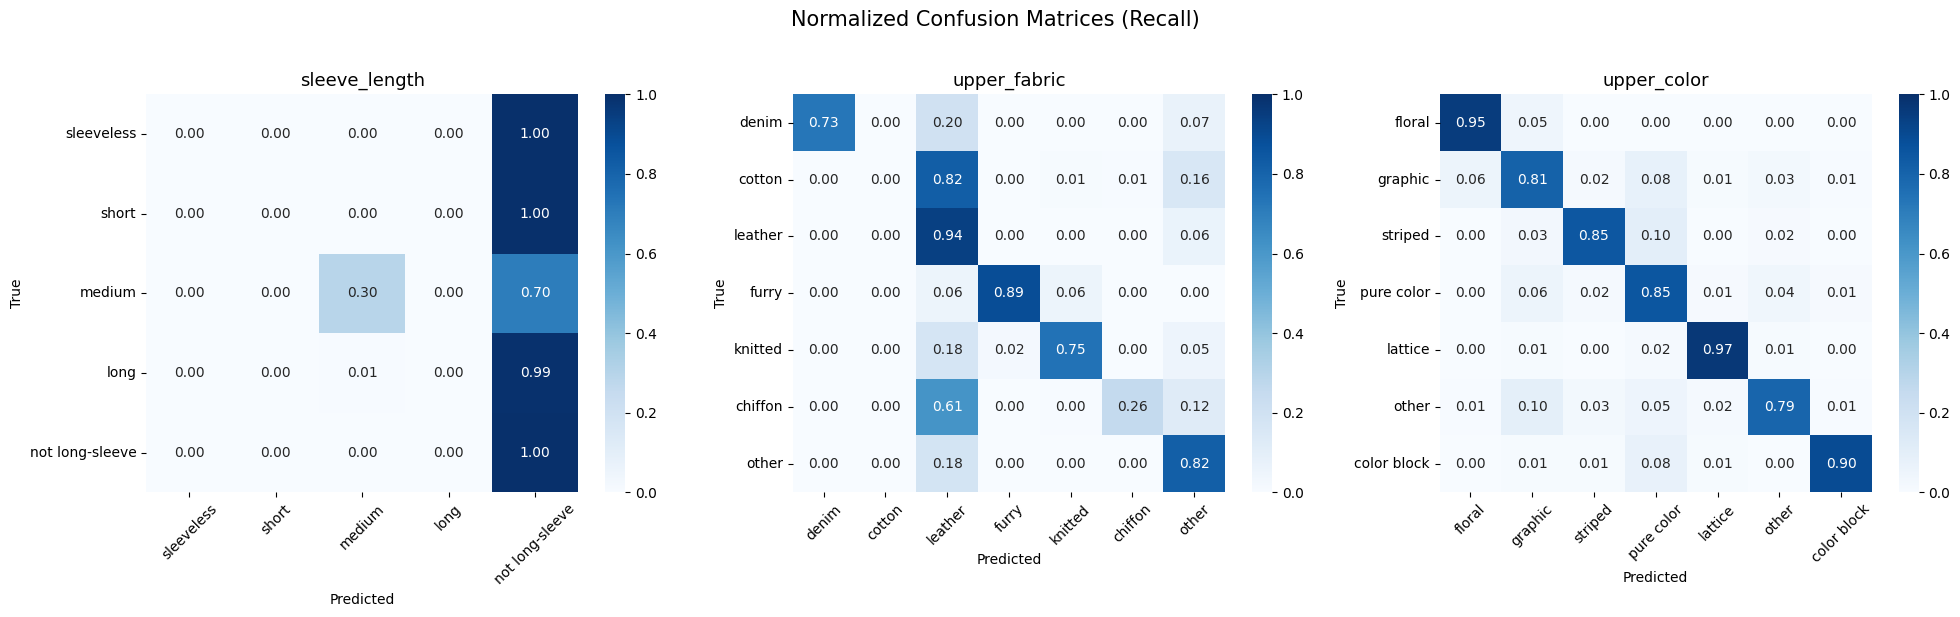

Saved: confusion_matrices.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, task in zip(axes, TASKS):
    label_names = [LABEL_MAPS[task][i] for i in range(TASKS[task])]

    cm = confusion_matrix(all_labels[task], all_preds[task])

    # Normalize by row (true label) to show recall per class
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names,
        ax=ax,
        vmin=0, vmax=1
    )
    ax.set_title(f"{task}", fontsize=13)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.suptitle("Normalized Confusion Matrices (Recall)", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

# 8 — Summary Table

In [9]:
from sklearn.metrics import f1_score, precision_score, recall_score

rows = []
for task in TASKS:
    acc       = (all_preds[task] == all_labels[task]).mean()
    f1_macro  = f1_score(all_labels[task], all_preds[task], average="macro",    zero_division=0)
    f1_weight = f1_score(all_labels[task], all_preds[task], average="weighted", zero_division=0)
    rows.append({
        "Task":          task,
        "Accuracy":      f"{acc:.4f}",
        "F1 Macro":      f"{f1_macro:.4f}",
        "F1 Weighted":   f"{f1_weight:.4f}",
    })

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

df_summary.to_csv(OUT_DIR / "evaluation_summary.csv", index=False)
print("\nSaved: evaluation_summary.csv")

         Task Accuracy F1 Macro F1 Weighted
sleeve_length   0.0169   0.0893      0.0237
 upper_fabric   0.0844   0.3682      0.0984
  upper_color   0.8438   0.7633      0.8504

Saved: evaluation_summary.csv


# 9 — Final Output Check

In [10]:
files = [
    OUT_DIR / "confusion_matrices.png",
    OUT_DIR / "evaluation_summary.csv",
]

print("Output files:")
for f in files:
    exists = f.exists()
    size   = f.stat().st_size / 1e3 if exists else 0
    print(f"  {'✅' if exists else '❌'} {f.name} ({size:.1f} KB)")

print("\nEvaluation complete.")
print(f"\nFinal Test Results:")
print(f"  upper_color   — Accuracy: 0.8438 | F1 Macro: 0.7633 ✅")
print(f"  upper_fabric  — Accuracy: 0.0844 | F1 Macro: 0.3682 ⚠️")
print(f"  sleeve_length — Accuracy: 0.0169 | F1 Macro: 0.0893 ❌")
print(f"\nNext: Notebook 05 — conclusions and improvements.")

Output files:
  ✅ confusion_matrices.png (205.5 KB)
  ✅ evaluation_summary.csv (0.1 KB)

Evaluation complete.

Final Test Results:
  upper_color   — Accuracy: 0.8438 | F1 Macro: 0.7633 ✅
  upper_fabric  — Accuracy: 0.0844 | F1 Macro: 0.3682 ⚠️
  sleeve_length — Accuracy: 0.0169 | F1 Macro: 0.0893 ❌

Next: Notebook 05 — conclusions and improvements.
